# Clustering

On utilise un notebook pour pouvoir afficher les sorties graphiques

In [23]:
from fonctions import load_gpkg, gdf_DBSCAN
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")



gdf["Annee"].unique()
gdf["aire"] = gdf.geometry.area

centroids = gdf.geometry.centroid
# Conversion en coordonnées géographiques (WGS84)
centroids_wgs84 = gpd.GeoSeries(centroids, crs=2154).to_crs(epsg=4326)
gdf["lat"] = centroids_wgs84.y
gdf["lon"] = centroids_wgs84.x

gdf=gdf[gdf["Annee"].isin([2008,2014,2020,2025])]



Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...
Chargement réussi (2958999 lignes)


In [32]:
gdf[(gdf["aire"] > 20000) & (gdf["Annee"] == 2025)]

,Annee,Dep,ORIGIN_BAT,NATURE,HAUTEUR,USAGE1,USAGE2,ETAT,DATE_CREAT,DATE_MAJ,ID_SOURCE,SOURCE,geometry,aire,lat,lon
318905,2025,81,Imagerie aérienne,"Industriel, agricole ou commercial",12.5,Industriel,None,En service,2006-12-21 13:35:24,2024-01-13 16:58:54,None,None,"POLYGON Z ((629266.8 6274649.5 170, 629257.1 6...",21234.630,43.568018,2.124811
321742,2025,81,Cadastre,"Industriel, agricole ou commercial",7.8,Industriel,None,En service,2014-11-24 15:16:47,2022-10-19 20:41:36,None,None,"POLYGON Z ((636246.8 6277045.1 179.3, 636252.7...",20263.960,43.589294,2.212066
322109,2025,81,Cadastre,"Industriel, agricole ou commercial",8.6,Commercial et services,None,En service,2014-11-24 16:15:06,2022-10-19 19:44:46,None,None,"POLYGON Z ((628413.4 6313925.7 175.8, 628430.2...",25941.520,43.920052,2.110064
322758,2025,81,Cadastre,"Industriel, agricole ou commercial",9.8,Commercial et services,None,En service,2014-11-25 17:21:08,2022-10-19 16:50:30,None,None,"POLYGON Z ((595994.9 6296914.3 122.6, 596040.7...",25602.710,43.762938,1.708595
323296,2025,81,Imagerie aérienne,"Industriel, agricole ou commercial",10.3,Commercial et services,None,En service,2014-11-26 18:27:54,2019-08-12 09:23:50,None,None,"POLYGON Z ((632179.4 6317953.6 173.6, 632180.7...",24536.870,43.956249,2.155010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958747,2025,95,Imagerie aérienne,"Industriel, agricole ou commercial",8.7,Commercial et services,None,En service,2022-09-29 15:55:16,None,None,None,"POLYGON Z ((660495.1 6874831.2 65.6, 660592.4 ...",25471.690,48.971232,2.460615
2958752,2025,95,Imagerie aérienne,"Industriel, agricole ou commercial",15.8,Industriel,None,En service,2022-09-29 15:55:29,2023-03-10 14:00:04,None,None,"POLYGON Z ((662221.5 6883395 117.9, 662219.6 6...",37432.115,49.048263,2.484578
2958753,2025,95,Imagerie aérienne,"Industriel, agricole ou commercial",14.1,Industriel,None,En service,2022-09-29 15:55:30,None,None,None,"POLYGON Z ((662293.8 6883519.2 121, 662295 688...",27414.320,49.051535,2.484221
2958943,2025,95,Cadastre,"Industriel, agricole ou commercial",13.5,Industriel,None,En service,2024-07-25 09:41:28,None,None,None,"POLYGON Z ((655534.5 6869307.3 50, 655524.2 68...",25702.565,48.922825,2.393595


Progress: 15/15 | eps : 281, clusters : 0.894, isolés : 0.106


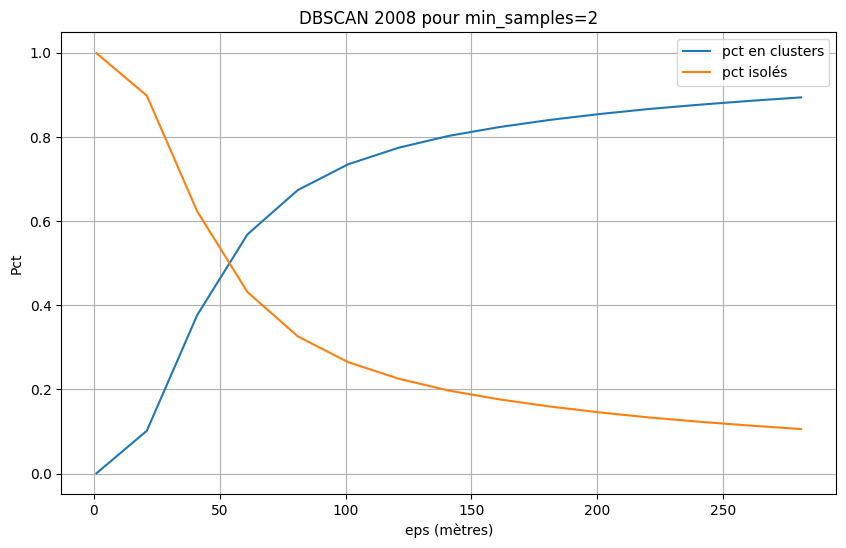

In [7]:
#clusters 
plot_DB_epsilon(gdf,2008,2,1,301,20)

In [36]:
from fonctions import plot_DB_epsilon

#identification de sites industriels et logistiques
temp, n_clusters, n_isoles =gdf_DBSCAN(gdf,2008,eps=50,min_samples=2)
isolés = temp[temp["cluster_id"] == -1].copy()
clusterisés = temp[temp["cluster_id"] != -1].copy()
clusterisés["centroid"] = clusterisés.geometry.centroid
clusters_fusionnes = clusterisés.groupby("cluster_id")["centroid"].apply(
    lambda centroids: Point(
        np.mean([p.x for p in centroids]),
        np.mean([p.y for p in centroids])
    )
).reset_index()
gdf_clusters_fusionnes = gpd.GeoDataFrame(
    clusters_fusionnes, 
    geometry="centroid", 
    crs=temp.crs
)
gdf_clusters_fusionnes = gdf_clusters_fusionnes.set_geometry("centroid")
temp = pd.concat([isolés, gdf_clusters_fusionnes], ignore_index=True)
temp.drop(columns=["cluster_id"], inplace=True)



Clusters détectés : 29753
Bâtiments isolés : 90743


Progress: 150/150 | eps : 2981, clusters : 0.997, isolés : 0.003


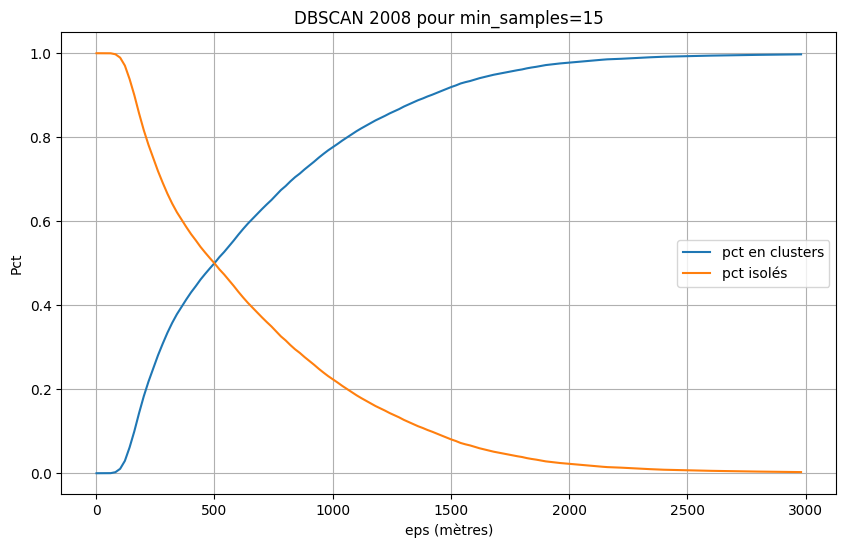

In [13]:
plot_DB_epsilon(gdf,2008,15,1,3001,20)

Progress: 40/40 | eps : 1951, clusters : 0.916, isolés : 0.084


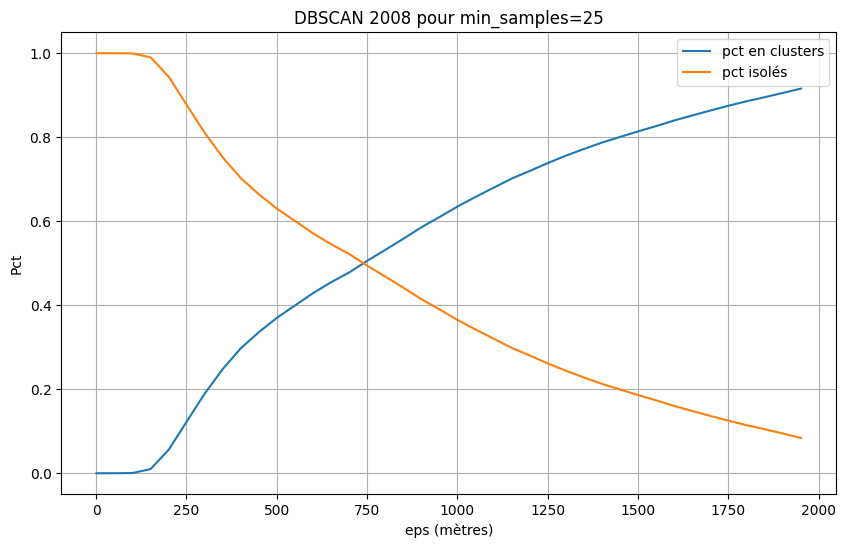

In [18]:
plot_DB_epsilon(gdf,2008,25,1,2001,50)

Progress: 100/100 | eps : 1981, clusters : 0.987, isolés : 0.013


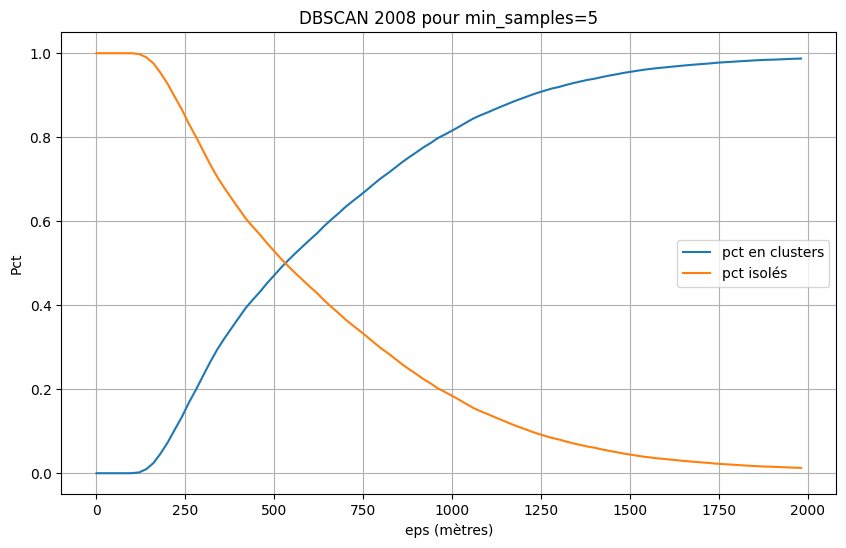

In [17]:
plot_DB_epsilon(temp,2008,5,1,2001)

Progress: 40/40 | eps : 1951, clusters : 0.995, isolés : 0.005


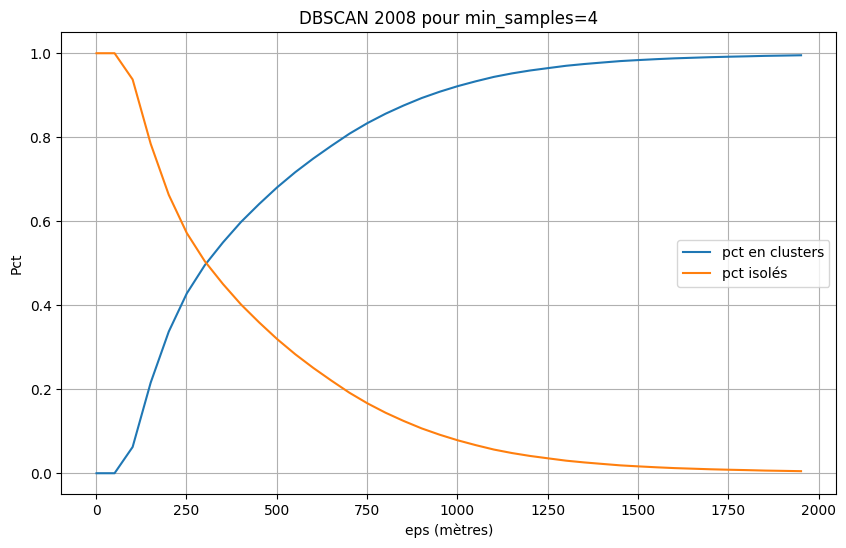

In [38]:
plot_DB_epsilon(temp,2008,4,1,2001,50)